In [1]:
from functools import partial
from pathlib import Path

from matplotlib import pyplot as plt
import numpy as np
from surfalize.addons_bv import operation_batch, process_files, parameters, operations, help_fncs
from surfalize import Surface
import pandas as pd

from surfalize.batch import Batch
def create_2d_array(df, rows_name_df, cols_name_df, value_name):
    rows = np.sort(df[rows_name_df].unique())
    cols = np.sort(df[cols_name_df].unique())
    array_2d = np.full((len(rows), len(cols)), np.nan)
    for i, fluence in enumerate(rows):
        for j, pulse in enumerate(cols):
            value = df[(df[rows_name_df] == fluence) & (df[cols_name_df] == pulse)][value_name]
            if not value.empty:
                array_2d[i, j] = value.values[0]
    return array_2d

In [2]:
# Read data
data_path = Path(r'E:\LocalData\EffPuls\Si\55fs\cropped_at_str_center_100um')
filename_pass='results_Si_55fsfs_fft-filter_P=5.32_filt-r=100_orders=7_type=pass.xlsx'
filename_stop='results_Si_55fsfs_fft-filter_P=5.32_filt-r=100_orders=7_type=stop.xlsx'
df_pass = pd.read_excel(data_path / filename_pass)
df_stop = pd.read_excel(data_path / filename_stop)

In [3]:
grouped = df_pass.groupby(['Pulse_Duration', 'Fluence', 'Pulses'])[['Sa', 'Sq', 'Sdr', 'height_mean', 'height_std']].mean().reset_index()
grouped['std_relative'] = grouped['height_std'] / grouped['height_mean'] * 100
df_pass = grouped

grouped = df_stop.groupby(['Pulse_Duration', 'Fluence', 'Pulses'])[['Sa', 'Sq', 'Sdr', 'height_mean', 'height_std']].mean().reset_index()
grouped['std_relative'] = grouped['height_std'] / grouped['height_mean'] * 100
df_stop = grouped

pulses = np.sort(df_pass['Pulses'].unique())
fluences = np.sort(df_pass['Fluence'].unique())

In [107]:
height_pass = create_2d_array(df_pass, 'Fluence', 'Pulses', value_name='height_mean')
stddev_pass = create_2d_array(df_pass, 'Fluence', 'Pulses', value_name='height_std')
sq_stop = create_2d_array(df_stop, 'Fluence', 'Pulses', value_name='Sq')


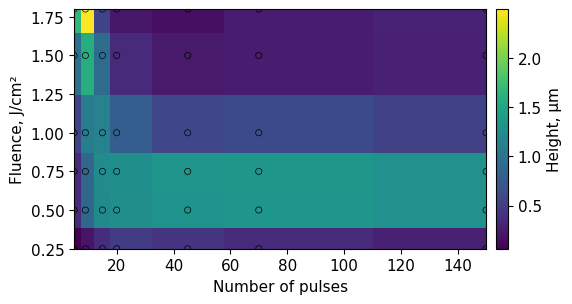

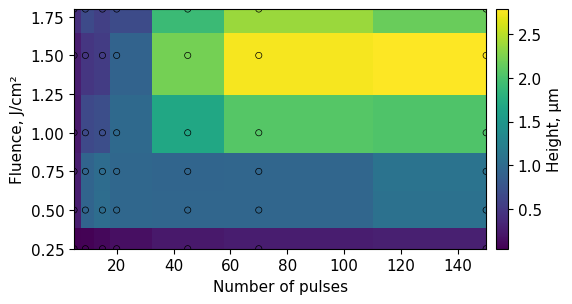

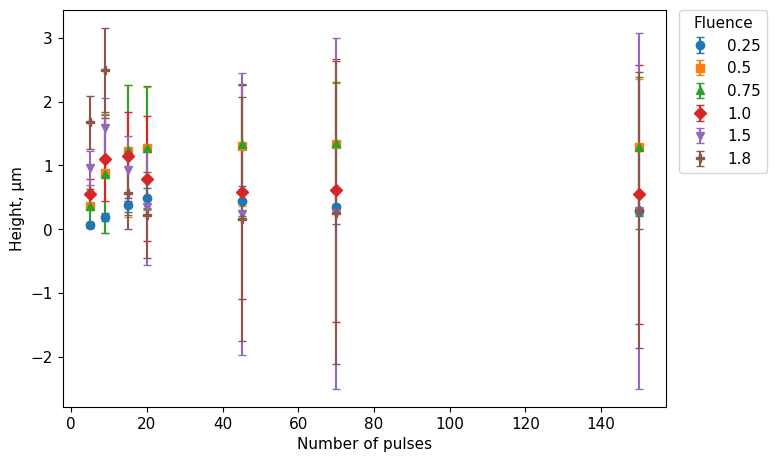

In [ ]:
import importlib
from surfalize.addons_bv import plotting
importlib.reload(plotting)

plotting.plot_heatmap(
    x=df_pass['Pulses'],
    y=df_pass['Fluence'],
    values=df_pass['height_mean'],
    figsize_cm=(15, 8),
    x_label='Number of pulses',
    y_label='Fluence, J/cm²',
    title='',
    colorbar_label='Height, µm',
    font_size_tick=11,
    font_size_label=11
)

plotting.plot_heatmap(
    x=df_stop['Pulses'],
    y=df_stop['Fluence'],
    values=df_stop['Sq'],
    figsize_cm=(15, 8),
    x_label='Number of pulses',
    y_label='Fluence, J/cm²',
    title='',
    colorbar_label='Height, µm',
    font_size_tick=11,
    font_size_label=11
)

plotting.plot_scatter(
    x=pulses, y=height_pass, 
    errors=None, 
    plot_legend_labels=fluences, 
    legend_title='Fluence', 
    figsize_cm=(20, 12), 
    x_title='Number of pulses', 
    y_title='Height, µm', 
    font_size_tick=11, 
    font_size_label=11)